In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

In [2]:
!gdown 19W-SCn-b7a7BQ6XEOk4Yaey7FLELqlV8

Downloading...
From: https://drive.google.com/uc?id=19W-SCn-b7a7BQ6XEOk4Yaey7FLELqlV8
To: C:\Users\ASUS\Desktop\Python\Perceptron-Learning\loan.csv

  0%|          | 0.00/9.16k [00:00<?, ?B/s]
100%|##########| 9.16k/9.16k [00:00<00:00, 9.31MB/s]


In [3]:
df = pd.read_csv('loan.csv')
df.head()

,x1,x2,y
0,3.729417,6.694052,rejected
1,6.282660,1.952843,approved
2,5.524101,2.296845,approved
3,-0.248258,5.732238,rejected
4,1.738760,4.701953,rejected


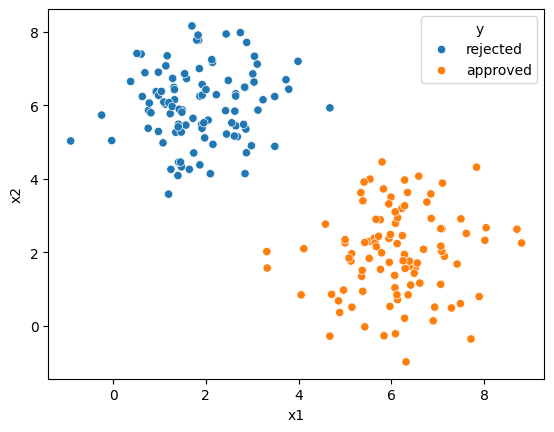

In [4]:
#Plotting the data distribution 

sns.scatterplot(x='x1', y='x2', data=df, hue='y')
plt.show()

In [5]:
#Data looks perfect to practice for Perceptron Algorithm

#Perceptron Algorithm involves 2 steps as following:
#1. Initialize a line with random weights and bias.
#2. Iterate till convergence:
    #1. For all the misclassified data points, add the weights to the datapoints
    #2. Add bias with the actual label.

In [6]:
#Creating a random line

w = np.random.normal(size=(2,))
w_0 = np.random.normal()

print(w, w_0)

[0.14851065 0.59487522] 0.20720156751987698


In [7]:
def dist_hyperplane(w, w_0, X):
    return (np.dot(w.T, X) + w_0)/np.linalg.norm(w)

In [8]:
def transform(x):
    if x=='rejected':
        return -1
    return 1

In [9]:
df['y'] = df['y'].apply(transform)

In [10]:
X = df.drop('y', axis = 1).values
y = df['y'].values

In [11]:
def show(w, w_0, X, y):
    x1 = np.array([0, 8])
    x2 = (-w[0]*x1-w_0)/w[1]
    plt.plot(x1, x2, 'r')
    sns.scatterplot(x=X[:, 0], y=X[:, 1], data=df, hue='y')
    plt.show()

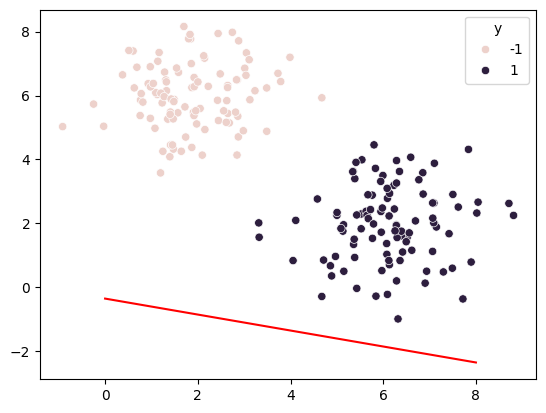

In [12]:
show(w, w_0, X, y)

In [13]:
def perceptron(w, w_0, X, y, num_iter=100):
    for itr in range(1, num_iter):
        print('Iteration Number:', itr)
        misclassified_points = 0
        for i in range(X.shape[0]):
            xi = X[i]
            yi = y[i]

            d = dist_hyperplane(w, w_0, X[i])
            sign = np.sign(d)
            if sign != y[i]:
                misclassified_points += 1
                w = w + (xi*yi)
                w_0 = w_0 + yi

        print('Total Misclassified Points:', misclassified_points)
        if misclassified_points==0:
            return w, w_0
    return w, w_0

In [14]:
w_best, w0_best = perceptron(w, w_0, X, y)

Iteration Number: 1
Total Misclassified Points: 4
Iteration Number: 2
Total Misclassified Points: 0


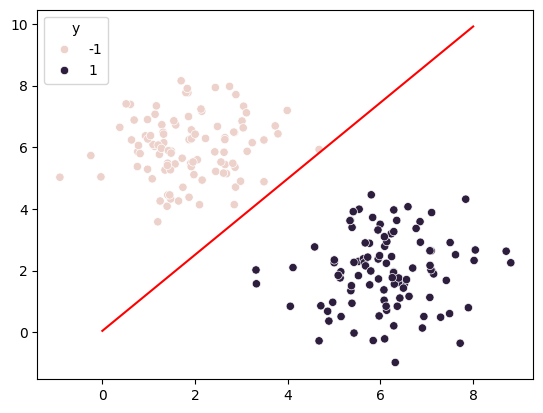

In [15]:
show(w_best, w0_best, X, y)

No Misclassfied points present now.
